<a href="https://colab.research.google.com/github/Zuhair0000/tensorflow_bootcamp/blob/main/06_transfer_learning_in_tensorflow_part_3_scaling_up.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Creating helper function

In [2]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py



--2026-02-18 16:39:50--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-02-18 16:39:50 (132 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

# Loading Data

In [4]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip

unzip_data("101_food_classes_10_percent.zip")

train_dir = '/content/101_food_classes_10_percent/train'
test_dir = '/content/101_food_classes_10_percent/test'

--2026-02-18 16:39:58--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.217.194.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1.5G) [application/zip]
Saving to: ‘101_food_classes_10_percent.zip’

101_food_classes_10 100%[===================>]   1.51G  22.6MB/s    in 71s     

2026-02-18 16:41:09 (22.0 MB/s) - ‘101_food_classes_10_percent.zip’ saved [1625420029/1625420029]



In [5]:
walk_through_dir('101_food_classes_10_percent')

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent/train'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/creme_brulee'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/hot_dog'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/pork_chop'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/prime_rib'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/takoyaki'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/carrot_cake'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/tiramisu'.
There are 0 directories and 75 images in '101_food_classes_10_percent/train/nachos'.
There are 0 directories and 75 images in '101_food_clas

In [6]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(train_dir,
                                                                 label_mode='categorical',
                                                                 image_size=(224, 224))
test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode='categorical',
                                                                image_size=(224, 224),
                                                                shuffle=False)

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


# Model Checkpoint

In [7]:
checkpoint_path = '101_classes_10_percent_data_model_checkpoint.keras'
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                        #  save_weights_only=True,
                                                         monitor='val_accuracy',
                                                         save_best_only=True)

In [8]:
from tensorflow.keras import layers

data_augmentaion = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.2),
    layers.RandomHeight(0.2),
    layers.RandomWidth(0.2),
    layers.RandomZoom(0.2),
], name='data_augmentation')

In [9]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)

base_model.trainable=False

inputs = tf.keras.Input(shape=(224, 224, 3), name='input_layer')

x = data_augmentaion(inputs)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D(name='global_avg_pool_layers')(x)

outputs = tf.keras.layers.Dense(len(train_data.class_names), activation='softmax', name='output_layer')(x)

model = tf.keras.Model(inputs, outputs)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
model.compile(loss='categorical_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'])

In [11]:
history = model.fit(train_data,
                    steps_per_epoch=len(train_data),
                    epochs=5,
                    validation_data = test_data,
                    validation_steps=int(0.15 * len(test_data)),
                    callbacks=[checkpoint_callback])

Epoch 1/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 99s 349ms/step - accuracy: 0.1322 - loss: 4.0774 - val_accuracy: 0.3909 - val_loss: 2.7500
Epoch 2/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 124s 289ms/step - accuracy: 0.4276 - loss: 2.6014 - val_accuracy: 0.4960 - val_loss: 2.2083
Epoch 3/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 60s 255ms/step - accuracy: 0.4884 - loss: 2.1983 - val_accuracy: 0.5167 - val_loss: 1.9984
Epoch 4/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 61s 257ms/step - accuracy: 0.5203 - loss: 1.9765 - val_accuracy: 0.5339 - val_loss: 1.8899
Epoch 5/5
237/237 ━━━━━━━━━━━━━━━━━━━━ 77s 236ms/step - accuracy: 0.5523 - loss: 1.8282 - val_accuracy: 0.5368 - val_loss: 1.8452


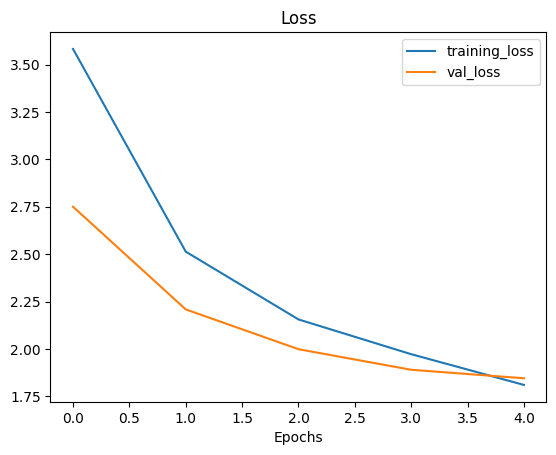

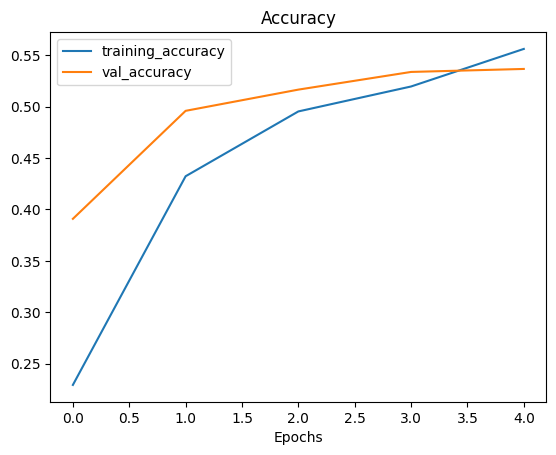

In [12]:
plot_loss_curves(history)

In [13]:
fine_tuning_results = model.evaluate(test_data)
fine_tuning_results

790/790 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.5444 - loss: 1.7651


[1.6545448303222656, 0.5655841827392578]

In [14]:
base_model.trainable = True

for layer in base_model.layers[:-5]:
  layer.trainable=False

In [15]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              metrics=['accuracy'])

In [16]:
history_fine_tuning = model.fit(train_data,
                                steps_per_epoch=len(train_data),
                                epochs=10,
                                validation_data = test_data,
                                validation_steps=int(0.15 * len(test_data)),
                                initial_epoch=history.epoch[-1],
                                callbacks=[checkpoint_callback])

Epoch 5/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 69s 234ms/step - accuracy: 0.5497 - loss: 1.9787 - val_accuracy: 0.5302 - val_loss: 1.9407
Epoch 6/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 50s 210ms/step - accuracy: 0.5915 - loss: 1.7986 - val_accuracy: 0.5421 - val_loss: 1.8426
Epoch 7/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 47s 199ms/step - accuracy: 0.5990 - loss: 1.6927 - val_accuracy: 0.5522 - val_loss: 1.7637
Epoch 8/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 46s 194ms/step - accuracy: 0.6109 - loss: 1.6406 - val_accuracy: 0.5567 - val_loss: 1.7271
Epoch 9/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 82s 193ms/step - accuracy: 0.6184 - loss: 1.5725 - val_accuracy: 0.5657 - val_loss: 1.6830
Epoch 10/10
237/237 ━━━━━━━━━━━━━━━━━━━━ 42s 177ms/step - accuracy: 0.6241 - loss: 1.5322 - val_accuracy: 0.5636 - val_loss: 1.6706


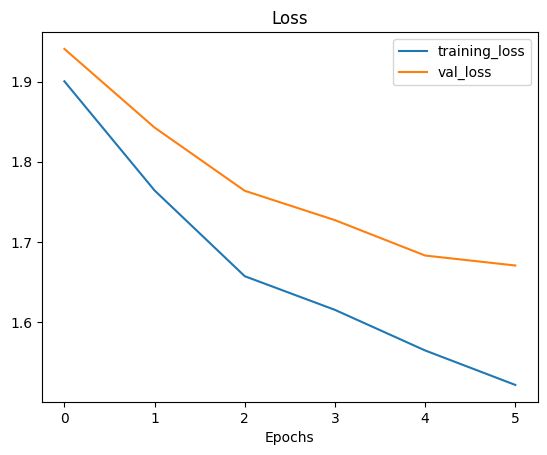

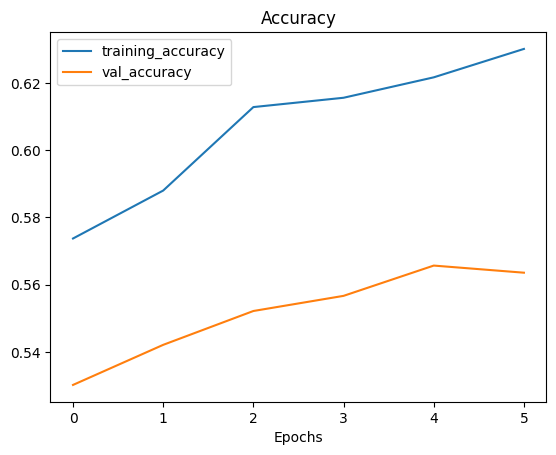

In [17]:
plot_loss_curves(history_fine_tuning)

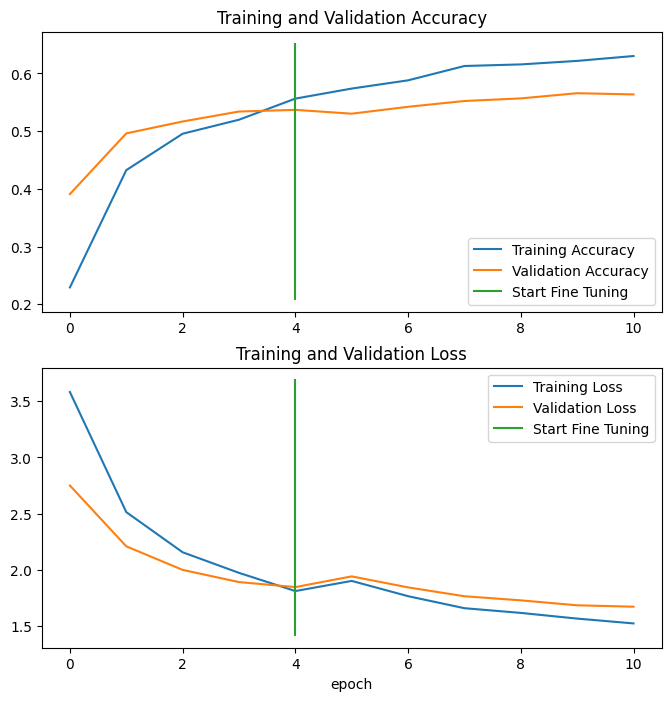

In [18]:
compare_historys(history, history_fine_tuning)

In [19]:
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip

--2026-02-18 16:55:05--  https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.24.207, 172.217.194.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.24.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46760742 (45M) [application/zip]
Saving to: ‘06_101_food_class_10_percent_saved_big_dog_model.zip’

06_101_food_class_1 100%[===================>]  44.59M  12.8MB/s    in 3.5s    

2026-02-18 16:55:08 (12.8 MB/s) - ‘06_101_food_class_10_percent_saved_big_dog_model.zip’ saved [46760742/46760742]



In [20]:
unzip_data('/content/06_101_food_class_10_percent_saved_big_dog_model.zip')

In [23]:
preds_probs = model.predict(test_data, verbose=1)

790/790 ━━━━━━━━━━━━━━━━━━━━ 58s 71ms/step


In [24]:
len(preds_probs)

25250

In [25]:
preds_probs.shape

(25250, 101)

In [26]:
print(f"Number of predictions probabilities for sample 0: {len(preds_probs[0])}")
print(f"What prediction probability sample 0 looks like: \n {preds_probs[0]}")
print(f"The class with the height predicted probability by the model for smample 0: {preds_probs[0].argmax()}")

Number of predictions probabilities for sample 0: 101
What prediction probability sample 0 looks like: 
 [8.8963583e-03 7.8655808e-04 1.3308720e-01 1.9031213e-05 2.7725910e-04
 1.1780023e-03 2.9109785e-04 1.7319304e-04 2.7726165e-03 7.6484005e-03
 1.8624114e-04 3.0167832e-04 1.0866226e-03 1.2634801e-04 1.7333295e-02
 6.2603354e-02 3.4777494e-03 4.6325945e-03 5.0904294e-03 4.7361846e-03
 9.8805195e-03 1.3685037e-04 4.4157860e-04 5.1840977e-04 8.8533078e-04
 8.6037945e-03 3.3839189e-03 2.1406561e-04 1.4220571e-02 1.4441874e-03
 1.0292916e-04 1.5697795e-03 1.2446179e-02 2.1209798e-03 2.1443229e-02
 5.4264825e-04 3.5262690e-03 5.9449552e-03 4.0291958e-02 7.2043150e-04
 2.0662975e-03 2.3153056e-03 6.9735775e-04 2.2735752e-03 4.9413438e-04
 9.9605077e-04 1.5682427e-03 4.5322278e-04 2.2616643e-03 4.4737067e-02
 1.3846362e-03 1.3327285e-03 3.6620446e-02 2.8265113e-02 2.0079498e-04
 3.6306591e-03 4.7640055e-03 6.1266022e-03 5.1807556e-03 1.2920950e-04
 1.4673000e-04 8.3888490e-03 7.0481338e-03 

In [28]:
test_data.class_names[52]

'gyoza'

In [30]:
pred_classes = preds_probs.argmax(axis=1)

pred_classes

array([85,  0,  0, ..., 56, 94, 52])

In [31]:
len(pred_classes)

25250